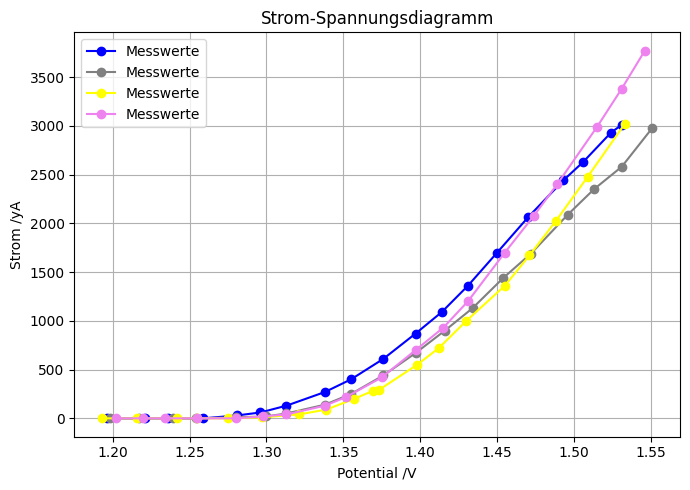

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy import log

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=6, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA","Potential 20 /V", "Strom 20 /yA","Potential 25 /V", "Strom 25 /yA","Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Kurve von 15°C
# Punkte zeichnen
plt.plot(df["Potential 15 /V"], df["Strom 15 /yA"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Kurve von 20°C
# Punkte zeichnen
plt.plot(df["Potential 20 /V"], df["Strom 20 /yA"], marker='o', linestyle='-', color='grey', label='Messwerte')

# Kurve von 25°C
# Punkte zeichnen
plt.plot(df["Potential 25 /V"], df["Strom 25 /yA"], marker='o', linestyle='-', color='yellow', label='Messwerte')

# Kurve von 30°C
# Punkte zeichnen
plt.plot(df["Potential 30 /V"], df["Strom 30 /yA"], marker='o', linestyle='-', color='violet', label='Messwerte')

# Achsen und Titel
plt.xlabel("Potential /V")
plt.ylabel("Strom /yA")
plt.title("Strom-Spannungsdiagramm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(df.head(19))

    Potential 15 /V  Strom 15 /yA  Potential 20 /V  Strom 20 /yA  \
0             1.196             0            1.198             0   
1             1.221             0            1.217             0   
2             1.236             0            1.239             0   
3             1.259             0            1.254             0   
4             1.281            30            1.280            10   
5             1.296            60            1.300            20   
6             1.313           130            1.313            50   
7             1.338           270            1.338           140   
8             1.355           400            1.355           250   
9             1.376           610            1.376           440   
10            1.397           870            1.397           670   
11            1.414          1090            1.416           900   
12            1.431          1360            1.434          1130   
13            1.450          1700            1.4

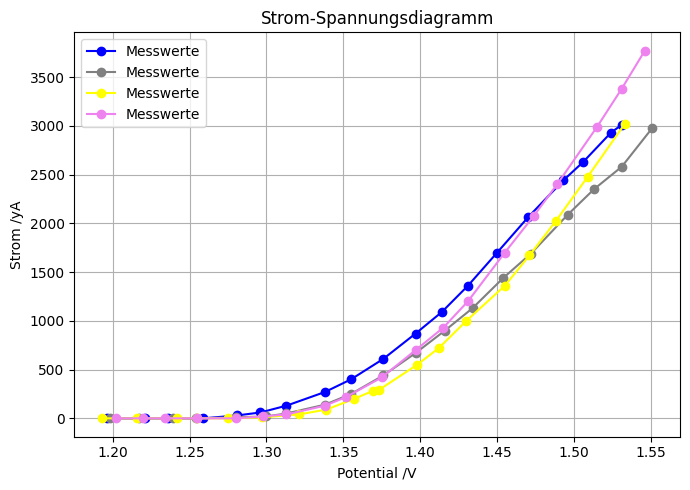

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy import log

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=6, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA",
              "Potential 20 /V", "Strom 20 /yA",
              "Potential 25 /V", "Strom 25 /yA",
              "Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Kurve von 15°C
# Punkte zeichnen
plt.plot(df["Potential 15 /V"], df["Strom 15 /yA"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Kurve von 20°C
# Punkte zeichnen
plt.plot(df["Potential 20 /V"], df["Strom 20 /yA"], marker='o', linestyle='-', color='grey', label='Messwerte')

# Kurve von 25°C
# Punkte zeichnen
plt.plot(df["Potential 25 /V"], df["Strom 25 /yA"], marker='o', linestyle='-', color='yellow', label='Messwerte')

# Kurve von 30°C
# Punkte zeichnen
plt.plot(df["Potential 30 /V"], df["Strom 30 /yA"], marker='o', linestyle='-', color='violet', label='Messwerte')

# Achsen und Titel
plt.xlabel("Potential /V")
plt.ylabel("Strom /yA")
plt.title("Strom-Spannungsdiagramm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

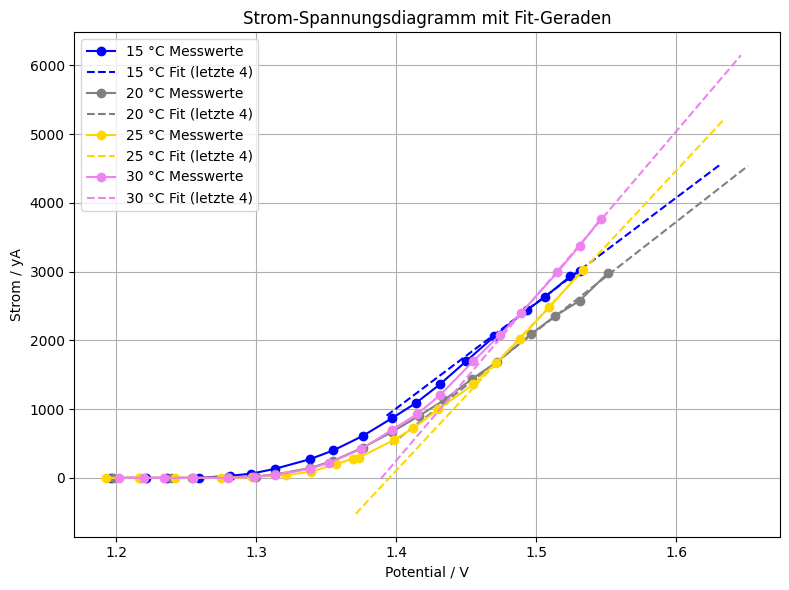

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=6, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA",
              "Potential 20 /V", "Strom 20 /yA",
              "Potential 25 /V", "Strom 25 /yA",
              "Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Farben & Bezeichnungen
# ===============================
farben = ["blue", "gray", "gold", "violet"]
temperaturen = ["15", "20", "25", "30"]

plt.figure(figsize=(8, 6))

# ===============================
# Für jede Temperatur:
# Plot & Fit-Gerade für die letzten 4 Punkte
# ===============================
for i, T in enumerate(temperaturen):
    x = df[f"Potential {T} /V"]
    y = df[f"Strom {T} /yA"]

    # Originalkurve zeichnen
    plt.plot(x, y, 'o-', color=farben[i], label=f"{T} °C Messwerte")

    # Fit durch letzte 4 Punkte
    x_fit = x.iloc[-4:]
    y_fit = y.iloc[-4:]
    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    poly = np.poly1d(coeffs)

    # Fit-Linie verlängert zeichnen
    x_line = np.linspace(x_fit.min() -0.1, x_fit.max() +0.1, 300)
    y_line = poly(x_line)
    plt.plot(x_line, y_line, linestyle='--', color=farben[i],
             label=f"{T} °C Fit (letzte 4)")

# ===============================
# Layout
# ===============================
plt.xlabel("Potential / V")
plt.ylabel("Strom / yA")
plt.title("Strom-Spannungsdiagramm mit Fit-Geraden")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

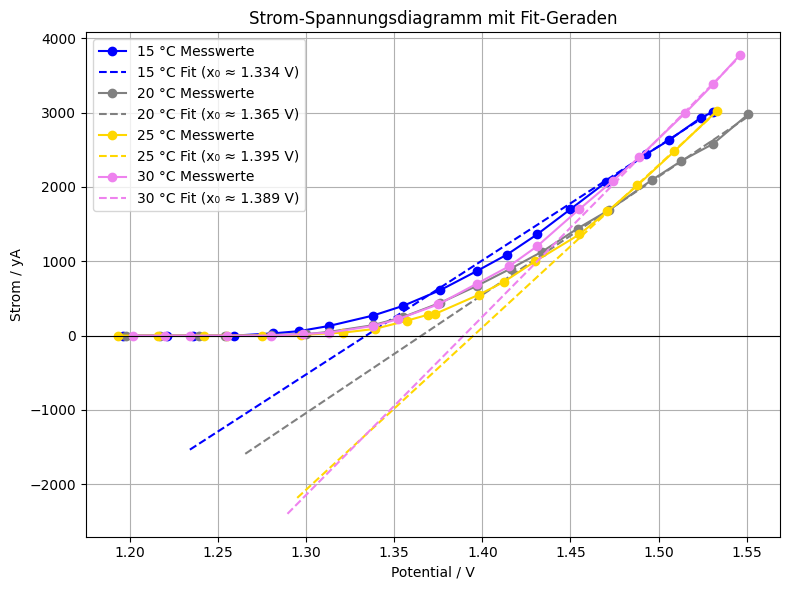

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=6, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA",
              "Potential 20 /V", "Strom 20 /yA",
              "Potential 25 /V", "Strom 25 /yA",
              "Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Farben & Bezeichnungen
# ===============================
farben = ["blue", "gray", "gold", "violet"]
temperaturen = ["15", "20", "25", "30"]

plt.figure(figsize=(8, 6))

# ===============================
# Für jede Temperatur:
# Plot & Fit-Gerade für die letzten 4 Punkte
# ===============================
for i, T in enumerate(temperaturen):
    x = df[f"Potential {T} /V"]
    y = df[f"Strom {T} /yA"]

    # Originalkurve zeichnen
    plt.plot(x, y, 'o-', color=farben[i], label=f"{T} °C Messwerte")

    # Fit durch letzte 4 Punkte
    x_fit = x.iloc[-4:]
    y_fit = y.iloc[-4:]
    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    poly = np.poly1d(coeffs)

    # Nullstellenberechnung: Schnitt mit x-Achse
    x_zero = -coeffs[1] / coeffs[0]

    # Fit-Linie zeichnen (erweitert)
    x_line = np.linspace(min(x_fit.min(), x_zero - 0.1), max(x_fit.max(), x_zero + 0.1), 300)
    y_line = poly(x_line)
    plt.plot(x_line, y_line, linestyle='--', color=farben[i],
             label=f"{T} °C Fit (x₀ ≈ {x_zero:.3f} V)")

# ===============================
# Layout
# ===============================
plt.axhline(0, color='black', linewidth=0.8)  # Nullstromlinie
plt.xlabel("Potential / V")
plt.ylabel("Strom / yA")
plt.title("Strom-Spannungsdiagramm mit Fit-Geraden")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

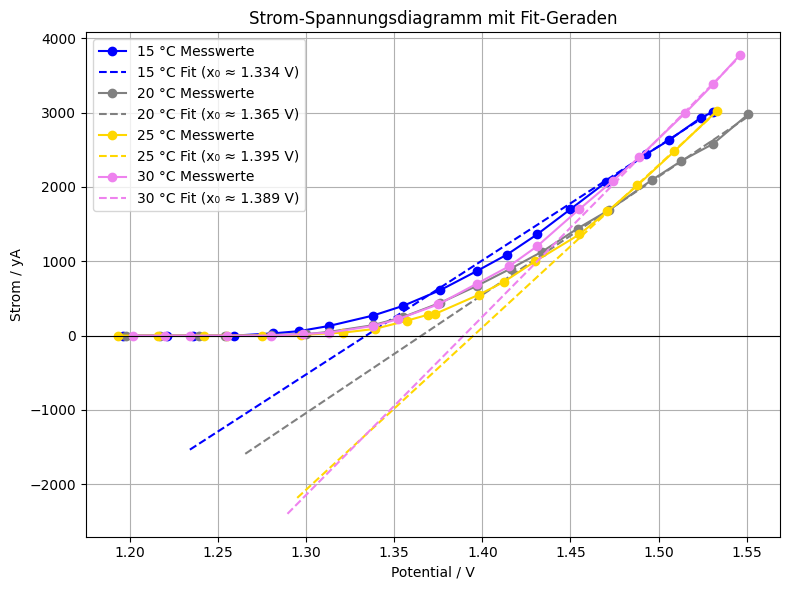

  Temperatur  x₀ (Schnittpunkt mit x-Achse)
0      15 °C                       1.334020
1      20 °C                       1.365456
2      25 °C                       1.394947
3      30 °C                       1.389408


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=6, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA",
              "Potential 20 /V", "Strom 20 /yA",
              "Potential 25 /V", "Strom 25 /yA",
              "Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Farben & Bezeichnungen
# ===============================
farben = ["blue", "gray", "gold", "violet"]
temperaturen = ["15", "20", "25", "30"]

plt.figure(figsize=(8, 6))
x_zeros = []  # Liste für Nullstellen

# ===============================
# Für jede Temperatur:
# Plot & Fit-Gerade für die letzten 4 Punkte
# ===============================
for i, T in enumerate(temperaturen):
    x = df[f"Potential {T} /V"]
    y = df[f"Strom {T} /yA"]

    # Originalkurve zeichnen
    plt.plot(x, y, 'o-', color=farben[i], label=f"{T} °C Messwerte")

    # Fit durch letzte 4 Punkte
    x_fit = x.iloc[-4:]
    y_fit = y.iloc[-4:]
    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    poly = np.poly1d(coeffs)

    # Nullstellenberechnung
    x_zero = -coeffs[1] / coeffs[0]
    x_zeros.append((f"{T} °C", x_zero))

    # Fit-Linie zeichnen
    x_line = np.linspace(min(x_fit.min(), x_zero - 0.1), max(x_fit.max(), x_zero + 0.1), 300)
    y_line = poly(x_line)
    plt.plot(x_line, y_line, linestyle='--', color=farben[i],
             label=f"{T} °C Fit (x₀ ≈ {x_zero:.3f} V)")

# ===============================
# Layout
# ===============================
plt.axhline(0, color='black', linewidth=0.8)  # Nullstromlinie
plt.xlabel("Potential / V")
plt.ylabel("Strom / yA")
plt.title("Strom-Spannungsdiagramm mit Fit-Geraden")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Nullstellen ausgeben
# ===============================
x_zeros_df = pd.DataFrame(x_zeros, columns=["Temperatur", "x₀ (Schnittpunkt mit x-Achse)"])
print(x_zeros_df)

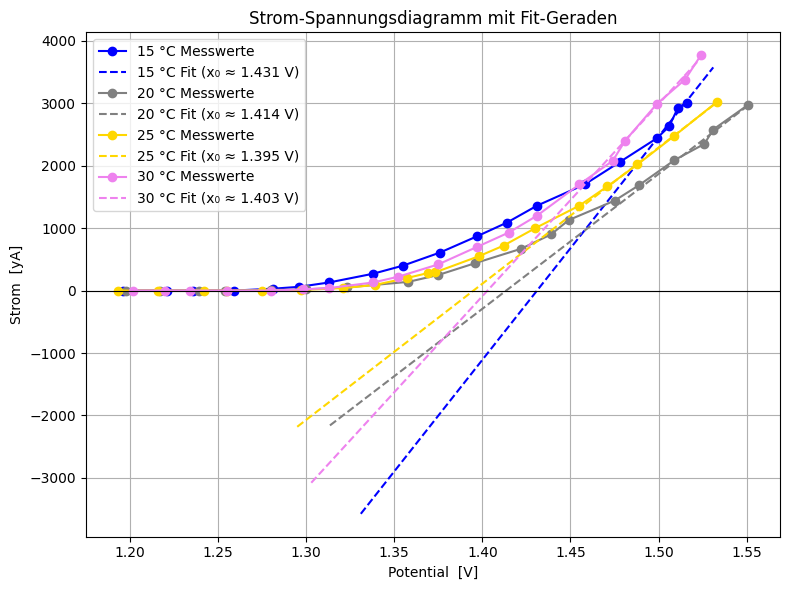

  Temperatur  x₀ (Schnittpunkt mit x-Achse)
0      15 °C                       1.431027
1      20 °C                       1.413510
2      25 °C                       1.394947
3      30 °C                       1.402916


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="E,F,H,I,K,L,N,O", skiprows=77, nrows=19)
df.columns = ["Potential 15 /V", "Strom 15 /yA",
              "Potential 20 /V", "Strom 20 /yA",
              "Potential 25 /V", "Strom 25 /yA",
              "Potential 30 /V", "Strom 30 /yA"]

# ===============================
# Farben & Bezeichnungen
# ===============================
farben = ["blue", "gray", "gold", "violet"]
temperaturen = ["15", "20", "25", "30"]

plt.figure(figsize=(8, 6))
x_zeros = []  # Liste für Nullstellen

# ===============================
# Für jede Temperatur:
# Plot & Fit-Gerade für die letzten 4 Punkte
# ===============================
for i, T in enumerate(temperaturen):
    x = df[f"Potential {T} /V"]
    y = df[f"Strom {T} /yA"]

    # Originalkurve zeichnen
    plt.plot(x, y, 'o-', color=farben[i], label=f"{T} °C Messwerte")

    # Fit durch letzte 4 Punkte
    x_fit = x.iloc[-4:]
    y_fit = y.iloc[-4:]
    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    poly = np.poly1d(coeffs)

    # Nullstellenberechnung
    x_zero = -coeffs[1] / coeffs[0]
    x_zeros.append((f"{T} °C", x_zero))

    # Fit-Linie zeichnen
    x_line = np.linspace(min(x_fit.min(), x_zero - 0.1), max(x_fit.max(), x_zero + 0.1), 300)
    y_line = poly(x_line)
    plt.plot(x_line, y_line, linestyle='--', color=farben[i],
             label=f"{T} °C Fit (x₀ ≈ {x_zero:.3f} V)")

# ===============================
# Layout
# ===============================
plt.axhline(0, color='black', linewidth=0.8)  # Nullstromlinie
plt.xlabel("Potential  [V]")
plt.ylabel("Strom  [yA]")
plt.title("Strom-Spannungsdiagramm mit Fit-Geraden")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Nullstellen ausgeben
# ===============================
x_zeros_df = pd.DataFrame(x_zeros, columns=["Temperatur", "x₀ (Schnittpunkt mit x-Achse)"])
print(x_zeros_df)